In [10]:
import os
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import scipy 

from dekef.base_density import *

import seaborn as sns
from IPython.display import Markdown as md

from matplotlib import ticker, cm

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import Ellipse
from dekef.kernel_function import *

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
# waiting = waiting[waiting != 108.0]
contam_data = 108.

In [3]:
info_coord = (0.03, 0.8)
info_coord1 = (0.03, 0.97)
info_coord2 = (0.03, 0.87)

In [4]:
label_fontsize = 25
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 30
linewidth = 4.0

In [5]:
bw = 5.0
kernel_type = 'gaussian_poly2'
xlimit = (1., 210.)
plot_pts_cnt = 3000
base_density = BasedenGamma(waiting, 36., 2.)

## comparison of ML and SM density estimates --- with 108

In [6]:
seed_no = 1
mlpen_folder = (f'../data/data=geyser-waiting-PenML-bw={bw}-kernel={kernel_type}-' + 
                f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                f'grid_points=1-202-1-seed={seed_no}-with108={108 in waiting}')

smpen_folder = (f'../data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
                f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                f'grid_points=1-202-1-with108={108 in waiting}')

smes_folder = (f'../data/data=geyser-waiting-EarlyStoppingSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
               f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
               f'grid_points=1-202-1-with108={108 in waiting}')

In [7]:
mlpen_list = [-np.inf, -15., -10., -6., -4., -3., -1., 1.][::-1]
smpen_list = [-12., -10.5, -10., -9., -7., -6., -5., -2.][::-1]
smiter_list = [10000, 3000, 2500, 300, 20, 5, 2, 0][::-1]

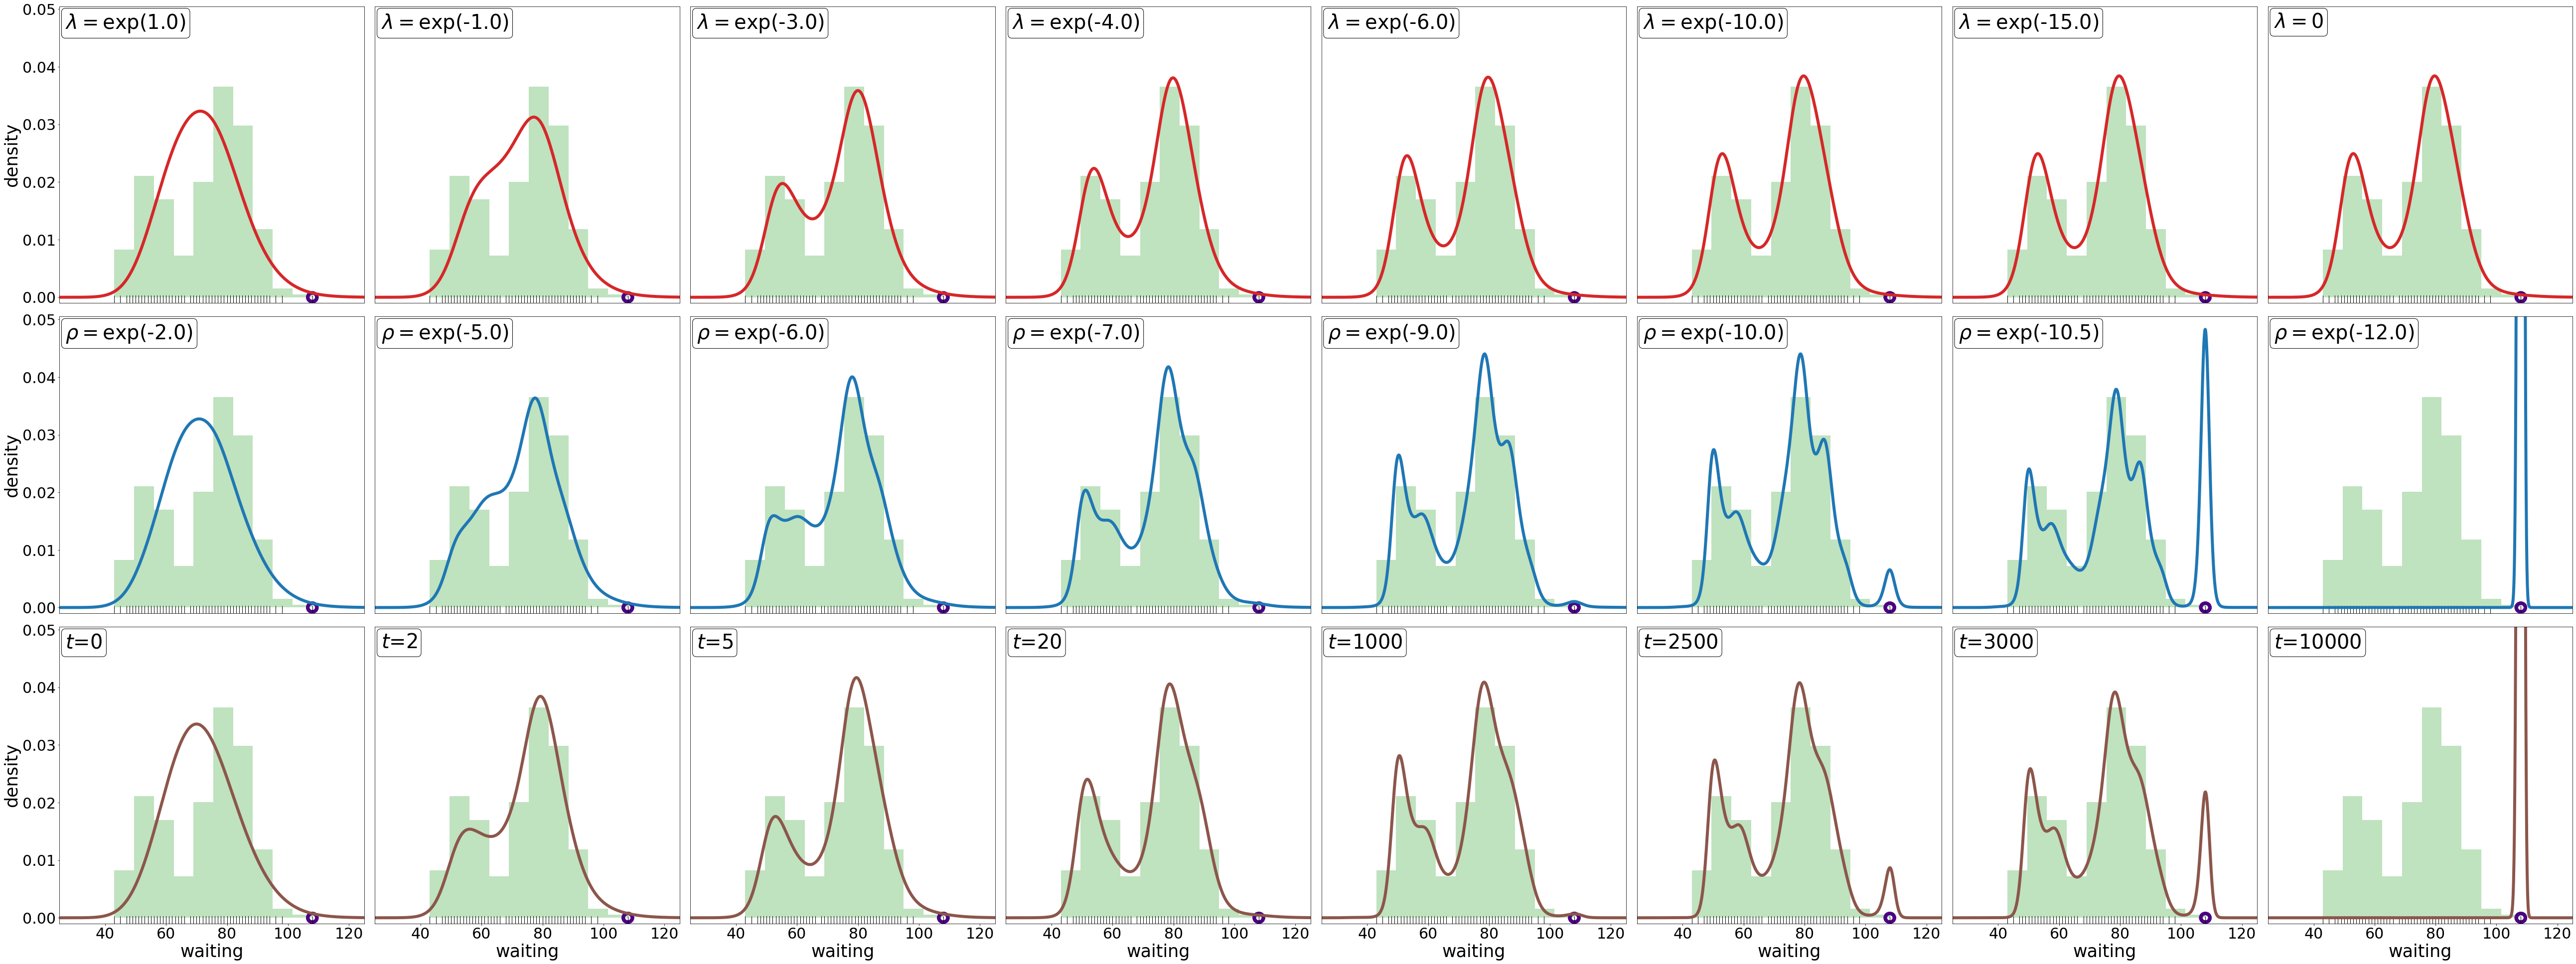

In [30]:
den_plot_xlim = (25., 125.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 6.0
x_label = r'waiting'
y_label = r'density'

nrows = 3
ncols = 8

fig = plt.figure(figsize=(72, 27))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120]

color1 = 'tab:red'
color2 = 'tab:blue'
color3 = 'tab:brown'

new_data = np.load(smpen_folder + f'/new_data.npy')

# ----------------------------------------------------------------------------------------
for i in range(len(mlpen_list)): 
    
    ax1 = fig.add_subplot(gs[0, i])
    contam_den = np.load(mlpen_folder + f'/logpenparam={mlpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color1)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    if i == len(mlpen_list) - 1: 
        info = r"$\lambda=${ll}".format(ll = 0)
    else: 
        info = r"$\lambda=$exp({ll})".format(ll = mlpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})
    

# ----------------------------------------------------------------------------------------
for i in range(len(smpen_list)): 
    
    ax1 = fig.add_subplot(gs[1, i])
    contam_den = np.load(smpen_folder + f'/logpenparam={smpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    info = r"$\rho=$exp({ll})".format(ll = smpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

for i in range(len(smiter_list)): 
    
    ax1 = fig.add_subplot(gs[2, i])
    contam_den = np.load(smes_folder + f'/iter_num={smiter_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color3)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')

    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
            
    info = r"$t$={ll}".format(ll = smiter_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/waiting-ML-vs-SM-density-estimates-baseden=Gamma-36-2-gridpoint=1-202-1-2.pdf', 
            bbox_inches = 'tight')
plt.show()


In [29]:
grid_points = np.arange(1., 202., 1).reshape(-1, 1)

kernel_function_grid = GaussianPoly2(data=grid_points.reshape(-1, 1), r1=1., r2=0., c=0., bw=bw)
gram = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

mlpen_list = [-np.inf, -15., -10., -6., -4., -3., -1., 1.][::-1]
smpen_list = [-12., -10.5, -10., -9., -7., -6., -5., -2.][::-1]
smiter_list = [10000, 3000, 2500, 1000, 20, 5, 2, 0][::-1]

norm_ml = []
norm_smpen = []
norm_smes = []

for i in range(len(mlpen_list)): 
    
    contam_coef = np.load(mlpen_folder + f'/logpenparam={mlpen_list[i]}-coef.npy').reshape(-1, 1)
    norm = contam_coef.T @ gram @ contam_coef
    norm_ml.append(np.sqrt(norm).item())

for i in range(len(smpen_list)): 
    
    contam_coef = np.load(smpen_folder + f'/logpenparam={smpen_list[i]}-coef.npy').reshape(-1, 1)
    norm = contam_coef.T @ gram @ contam_coef
    norm_smpen.append(np.sqrt(norm).item())

for i in range(len(smiter_list)): 
    
    contam_coef = np.load(smes_folder + f'/iter_num={smiter_list[i]}-coef.npy').reshape(-1, 1)
    norm = contam_coef.T @ gram @ contam_coef
    norm_smes.append(np.sqrt(norm).item())

pd.DataFrame({'MLpen_val': mlpen_list, 'MLpen_norm': norm_ml, 
              'SMpen_val': smpen_list, 'SMpen_norm': norm_smpen, 
              'SMes_val': smiter_list, 'SMes_norm': norm_smes})

,MLpen_val,MLpen_norm,SMpen_val,SMpen_norm,SMes_val,SMes_norm
0,1.0,0.091643,-2.0,0.068092,0,0.000000
1,-1.0,0.484443,-5.0,0.891391,2,1.131922
2,-3.0,1.296544,-6.0,1.582355,5,1.737217
3,-4.0,1.669436,-7.0,2.473170,20,2.356688
4,-6.0,1.985734,-9.0,6.061466,1000,5.493986
5,-10.0,2.042754,-10.0,10.304497,2500,10.618348
6,-15.0,2.043852,-10.5,13.749247,3000,12.529501
7,-inf,2.043860,-12.0,39.783524,10000,41.335871


## comparison of ML and SM density estimates --- no 108

In [31]:
seed_no = 1
waiting = waiting[waiting != 108.]
mlpen_folder = (f'../data/data=geyser-waiting-PenML-bw={bw}-kernel={kernel_type}-' + 
                f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                f'grid_points=1-202-1-seed={seed_no}-with108={108 in waiting}')

smpen_folder = (f'../data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
                f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                f'grid_points=1-202-1-with108={108 in waiting}')

smes_folder = (f'../data/data=geyser-waiting-EarlyStoppingSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
               f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
               f'grid_points=1-202-1-with108={108 in waiting}')

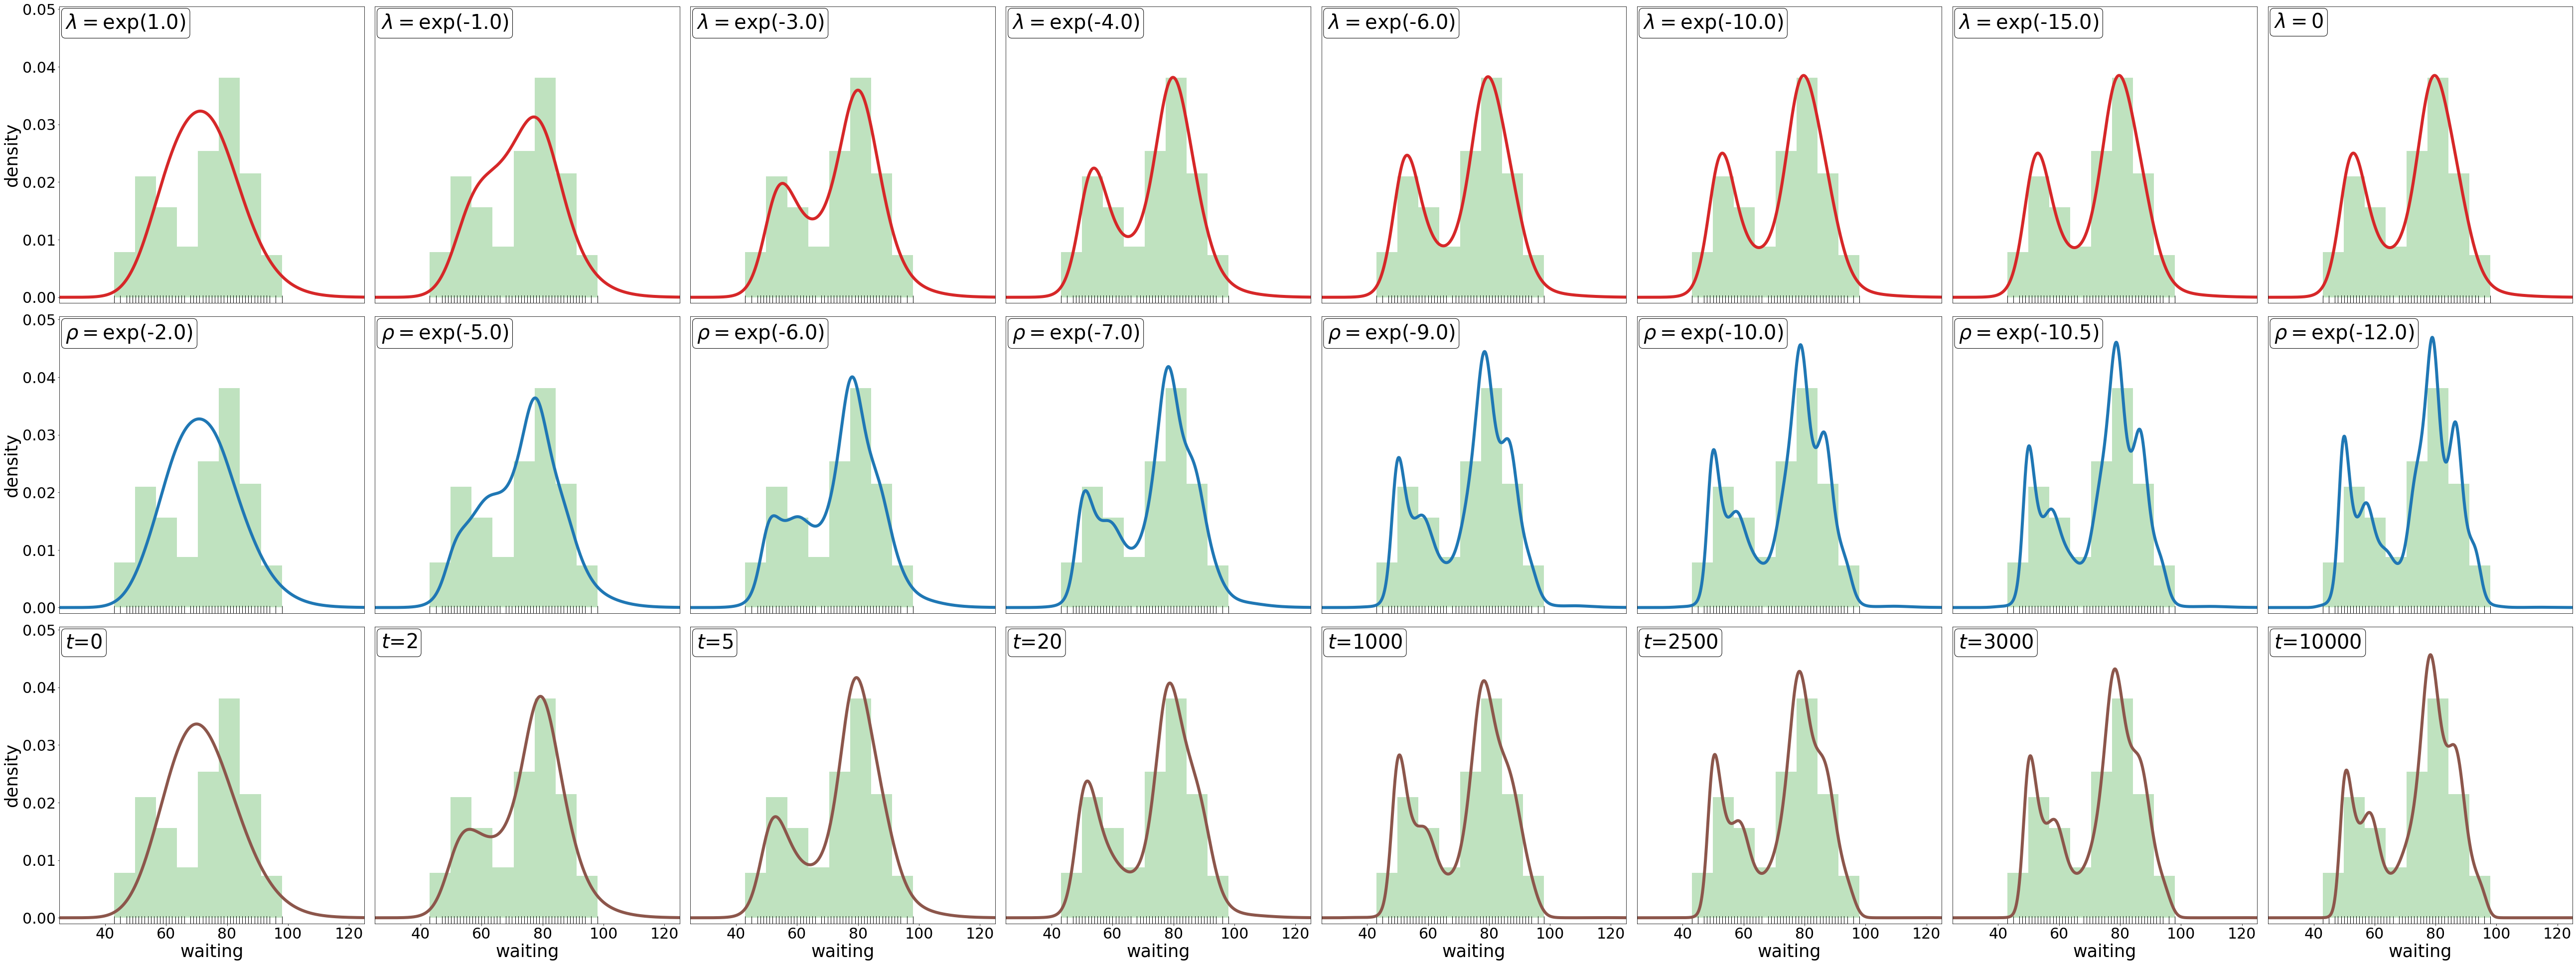

In [32]:
den_plot_xlim = (25., 125.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

sm_logpen = -8.

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 6.0
x_label = r'waiting'
y_label = r'density'

nrows = 3
ncols = 8

fig = plt.figure(figsize=(72, 27))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120]

color1 = 'tab:red'
color2 = 'tab:blue'
color3 = 'tab:brown'

new_data = np.load(smpen_folder + f'/new_data.npy')

# ----------------------------------------------------------------------------------------
for i in range(len(mlpen_list)): 
    
    ax1 = fig.add_subplot(gs[0, i])
    contam_den = np.load(mlpen_folder + f'/logpenparam={mlpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color =  color1)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
#     ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
#                                          color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    if i == len(mlpen_list) - 1: 
        info = r"$\lambda=${ll}".format(ll = 0)
    else: 
        info = r"$\lambda=$exp({ll})".format(ll = mlpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})
    

# ----------------------------------------------------------------------------------------
for i in range(len(smpen_list)): 
    
    ax1 = fig.add_subplot(gs[1, i])
    contam_den = np.load(smpen_folder + f'/logpenparam={smpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
#     ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
#                                          color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    info = r"$\rho=$exp({ll})".format(ll = smpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

for i in range(len(smiter_list)): 
    
    ax1 = fig.add_subplot(gs[2, i])
    contam_den = np.load(smes_folder + f'/iter_num={smiter_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color3)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    
#     ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
#                                          color = 'indigo', fill = False, linewidth = 7.0)))

    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
            
    info = r"$t$={ll}".format(ll = smiter_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/waiting-ML-vs-SM-density-estimates-baseden=Gamma-36-2-gridpoint=1-202-1-no108-2.pdf', 
            bbox_inches = 'tight')
plt.show()
